In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv('loan_approval_dataset.csv')

In [5]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [7]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [8]:
df.shape


(4269, 13)

In [9]:
df.columns = df.columns.str.strip()

In [10]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [11]:
numerical_col = df[[
    'no_of_dependents',
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]]

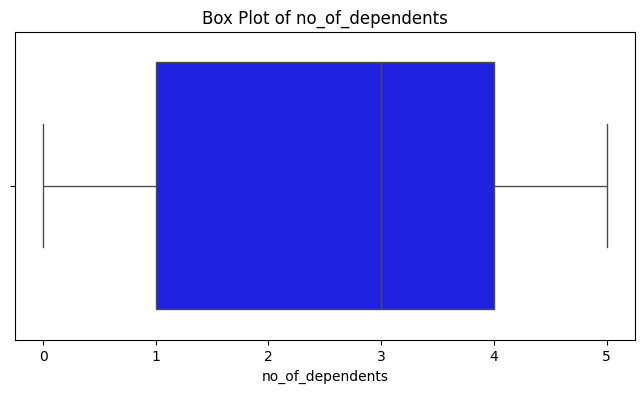

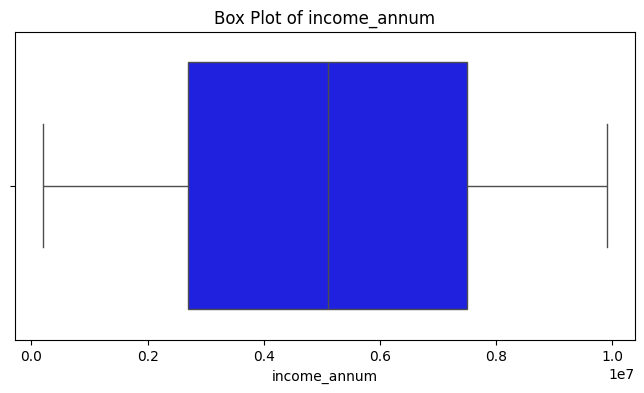

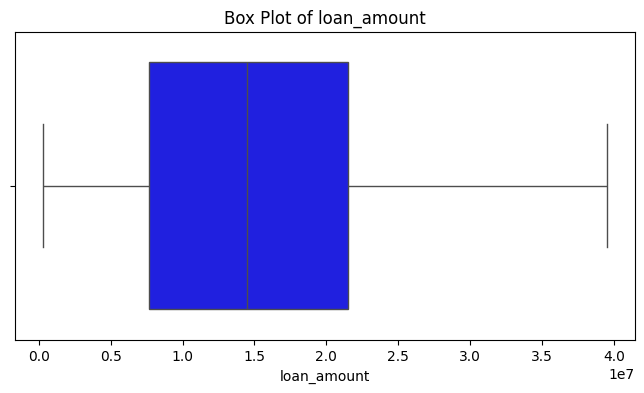

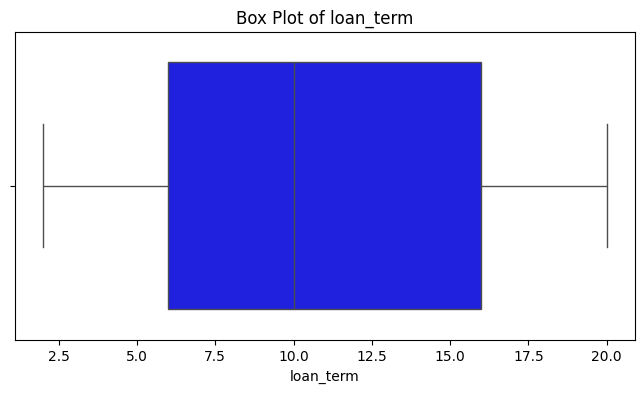

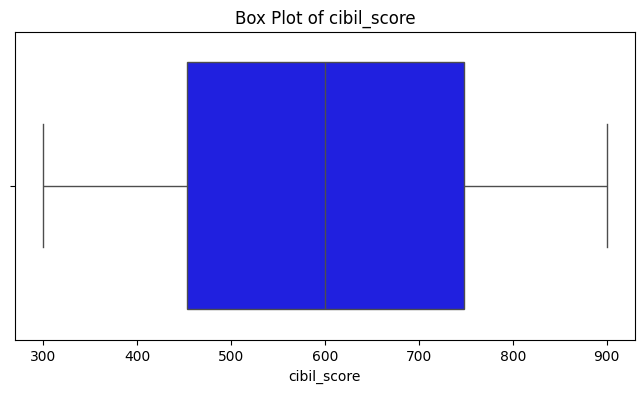

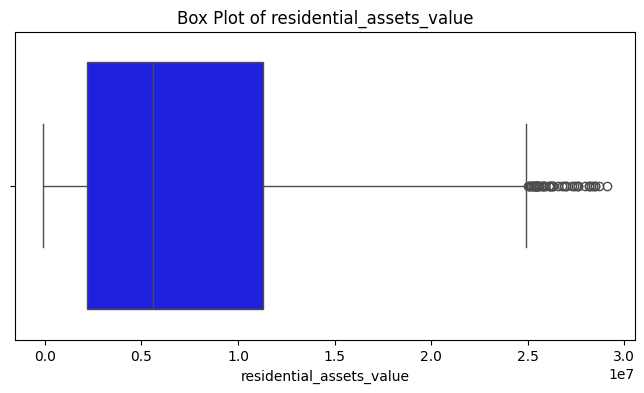

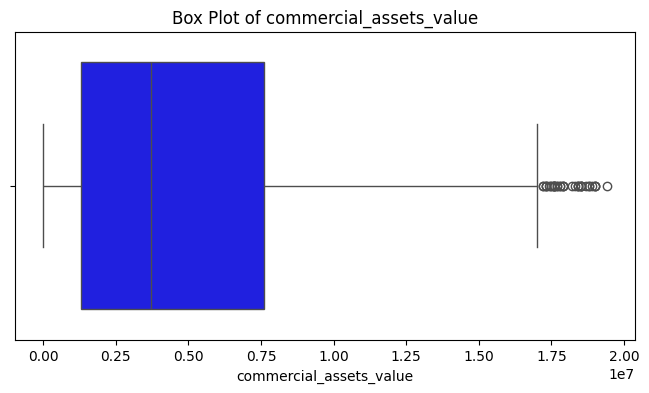

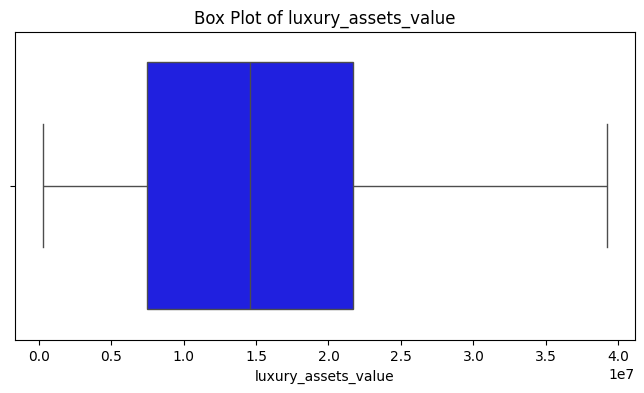

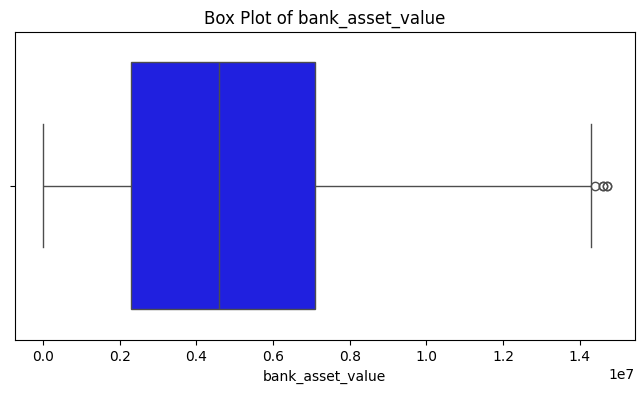

In [12]:
for col in numerical_col:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col], color='blue')
    plt.title(f'Box Plot of {col}')
    plt.show()

In [13]:
df['residential_assets_value'].value_counts()

residential_assets_value
400000      66
500000      63
100000      60
1000000     57
600000      56
            ..
27500000     1
25000000     1
23100000     1
27400000     1
27300000     1
Name: count, Length: 278, dtype: int64

In [14]:
(df['residential_assets_value'] < 0).sum()

np.int64(28)

In [15]:
asset_cols = [
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]

for col in asset_cols:
    print(col, (df[col] < 0).sum())

residential_assets_value 28
commercial_assets_value 0
luxury_assets_value 0
bank_asset_value 0


In [16]:
print(df['residential_assets_value'].describe())

count    4.269000e+03
mean     7.472617e+06
std      6.503637e+06
min     -1.000000e+05
25%      2.200000e+06
50%      5.600000e+06
75%      1.130000e+07
max      2.910000e+07
Name: residential_assets_value, dtype: float64


In [17]:
df['residential_assets_value'] = df['residential_assets_value'].replace(-100000, np.nan)

In [18]:
df['residential_assets_value'].fillna(
    df['residential_assets_value'].median(),
    inplace=True
)

In [19]:
df['residential_assets_value'].describe()

count    4.269000e+03
mean     7.510658e+06
std      6.476129e+06
min      0.000000e+00
25%      2.200000e+06
50%      5.700000e+06
75%      1.130000e+07
max      2.910000e+07
Name: residential_assets_value, dtype: float64

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.head(5)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000.0,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000.0,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000.0,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000.0,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000.0,8200000,29400000,5000000,Rejected


<Axes: xlabel='education', ylabel='income_annum'>

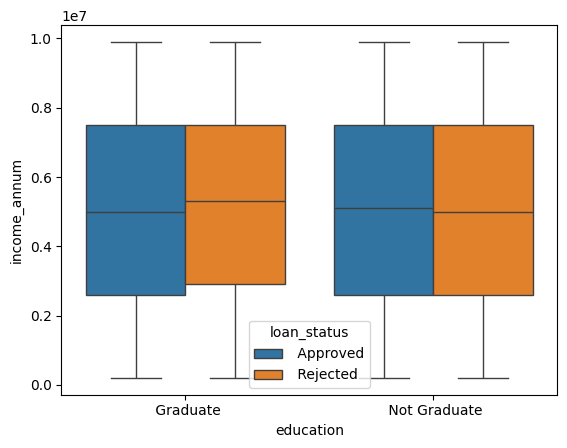

In [22]:
sns.boxplot(x=df['education'], y=df['income_annum'], hue=df['loan_status'])

<Axes: xlabel='education', ylabel='count'>

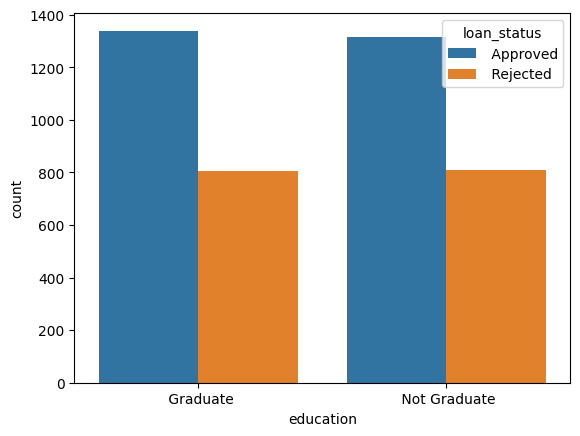

In [23]:
sns.countplot(x=df['education'], hue=df['loan_status'])

In [24]:
df.head(5)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000.0,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000.0,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000.0,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000.0,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000.0,8200000,29400000,5000000,Rejected


In [25]:
df.drop(columns=['loan_id'], inplace=True)

In [26]:
df.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

In [27]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000.0,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000.0,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000.0,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000.0,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000.0,8200000,29400000,5000000,Rejected


<Axes: >

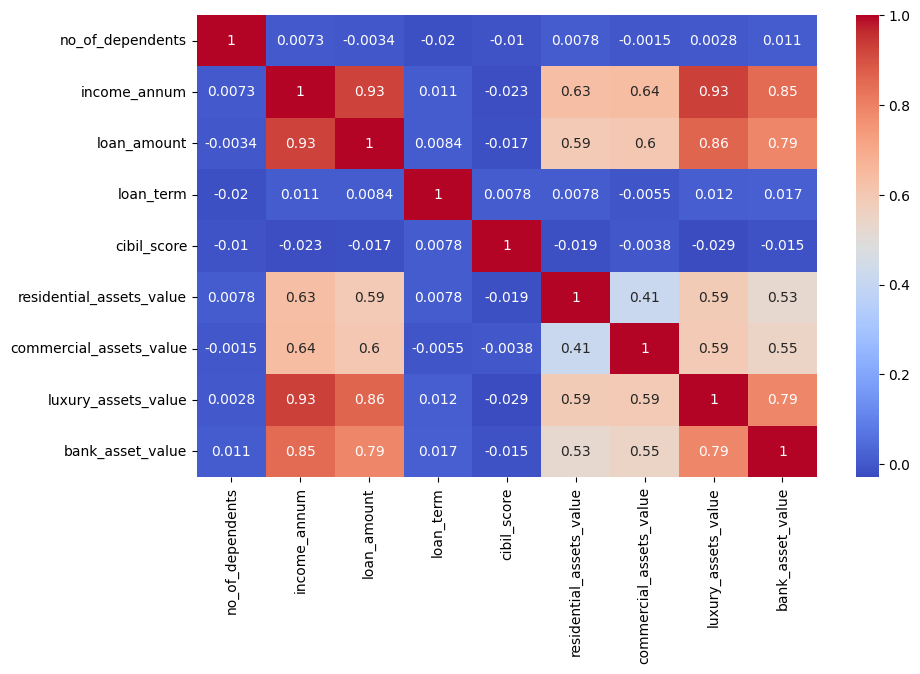

In [28]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [29]:
df_cleaned = pd.get_dummies(df,drop_first=True)

In [30]:
df_cleaned = df_cleaned.astype(int)

In [31]:
df_cleaned

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_ Not Graduate,self_employed_ Yes,loan_status_ Rejected
0,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0,0,0
1,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1,1,1
2,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,0,1
3,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,0,1
4,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1000000,2300000,12,317,2800000,500000,3300000,800000,0,1,1
4265,0,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1,1,0
4266,2,6500000,23900000,18,457,1200000,12400000,18100000,7300000,1,0,1
4267,1,4100000,12800000,8,780,8200000,700000,14100000,5800000,1,0,0


In [32]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [33]:
numerical_cols = [
    'no_of_dependents',
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]

In [34]:
df_cleaned[numerical_cols] = scaler.fit_transform(df_cleaned[numerical_cols])

In [35]:
df_cleaned.columns

Index(['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
       'cibil_score', 'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'education_ Not Graduate',
       'self_employed_ Yes', 'loan_status_ Rejected'],
      dtype='object')

In [36]:
X = df_cleaned.drop('loan_status_ Rejected', axis=1)
y = df_cleaned['loan_status_ Rejected']

In [37]:
from scipy.stats import pearsonr


correlation_results = []

for col in numerical_cols:
    corr, p = pearsonr(X[col], y)
    correlation_results.append([col, corr, p])

correlation_df = pd.DataFrame(
    correlation_results,
    columns=['Feature', 'Correlation', 'P-value']
)

correlation_df = correlation_df.sort_values(
    by='Correlation',
    key=abs,
    ascending=False
)

print(correlation_df)

                    Feature  Correlation       P-value
4               cibil_score    -0.770518  0.000000e+00
3                 loan_term     0.113036  1.291185e-13
0          no_of_dependents     0.018114  2.366890e-01
2               loan_amount    -0.016150  2.914523e-01
7       luxury_assets_value     0.015465  3.124036e-01
1              income_annum     0.015189  3.211051e-01
5  residential_assets_value     0.015042  3.258086e-01
6   commercial_assets_value    -0.008246  5.901515e-01
8          bank_asset_value     0.006778  6.579377e-01


In [38]:
cat_features = [
    'education_ Not Graduate',
     'self_employed_ Yes'
]

In [39]:
from scipy.stats import chi2_contingency

alpha = 0.05

chi2_results = {}

for col in cat_features:

    contingency = pd.crosstab(
        X[col],
        y
    )

    chi2_stat, p_value, dof, expected = chi2_contingency(contingency)

    if p_value < alpha:
        decision = "Reject Null (Keep Feature)"
    else:
        decision = "Accept Null (Drop Feature)"

    chi2_results[col] = [
        chi2_stat,
        p_value,
        decision
    ]

chi2_df = pd.DataFrame(
    chi2_results,
    index=["Chi2 Statistic","P-value","Decision"]
).T

print(chi2_df)

                        Chi2 Statistic   P-value                    Decision
education_ Not Graduate       0.083958  0.772004  Accept Null (Drop Feature)
self_employed_ Yes                 0.0       1.0  Accept Null (Drop Feature)


In [40]:
X = X.drop(
    columns=['education_ Not Graduate', 'self_employed_ Yes']
)

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [42]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

In [43]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(kernel='rbf')
}

In [44]:
result = []

In [45]:
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    result.append({
        'model': name,
        'Accuracy': round(acc, 4),
        'f1 score': round(f1, 4)
    })

In [46]:
result

[{'model': 'Logistic Regression', 'Accuracy': 0.9075, 'f1 score': 0.8748},
 {'model': 'KNN', 'Accuracy': 0.9133, 'f1 score': 0.8851},
 {'model': 'Naive Bayes', 'Accuracy': 0.9379, 'f1 score': 0.9186},
 {'model': 'Decision Tree', 'Accuracy': 0.9719, 'f1 score': 0.9624},
 {'model': 'SVM', 'Accuracy': 0.9391, 'f1 score': 0.9187}]

In [47]:
from sklearn.ensemble import RandomForestClassifier


In [48]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)


In [49]:
model_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
y_pred_rf = model_rf.predict(X_test)

In [51]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_rf

0.9800936768149883

In [52]:
f1_rf = f1_score(y_test, y_pred_rf)

In [53]:
f1_rf

0.9730586370839936

In [54]:
from sklearn.model_selection import GridSearchCV

In [55]:
model_gc = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid={
        'n_estimators': [50, 100, 200],
        'max_depth': [5,10,15,None],
        'min_samples_split': [2, 5, 10],
        
    },
    cv=5,
    scoring='accuracy',
    n_jobs=1
)

In [60]:
from xgboost import XGBClassifier

In [61]:
model_xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

model_xgb.fit(X_train,y_train)

y_pred = model_xgb.predict(X_test)

print(accuracy_score(y_test,y_pred))

0.9800936768149883


In [62]:
f1_xgb = f1_score(y_test, y_pred)

print(f1_xgb)

0.9731437598736177


In [63]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

print(cm)

[[530   6]
 [ 11 307]]


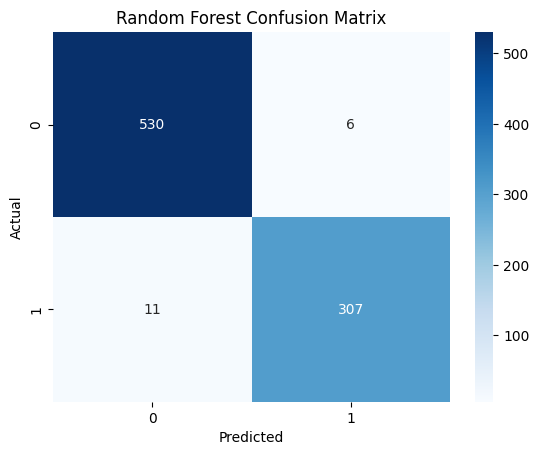

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [65]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [66]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": model_rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                    Feature  Importance
4               cibil_score    0.828141
3                 loan_term    0.060773
2               loan_amount    0.030418
1              income_annum    0.017925
7       luxury_assets_value    0.015448
5  residential_assets_value    0.013786
6   commercial_assets_value    0.013258
8          bank_asset_value    0.013230
0          no_of_dependents    0.007022


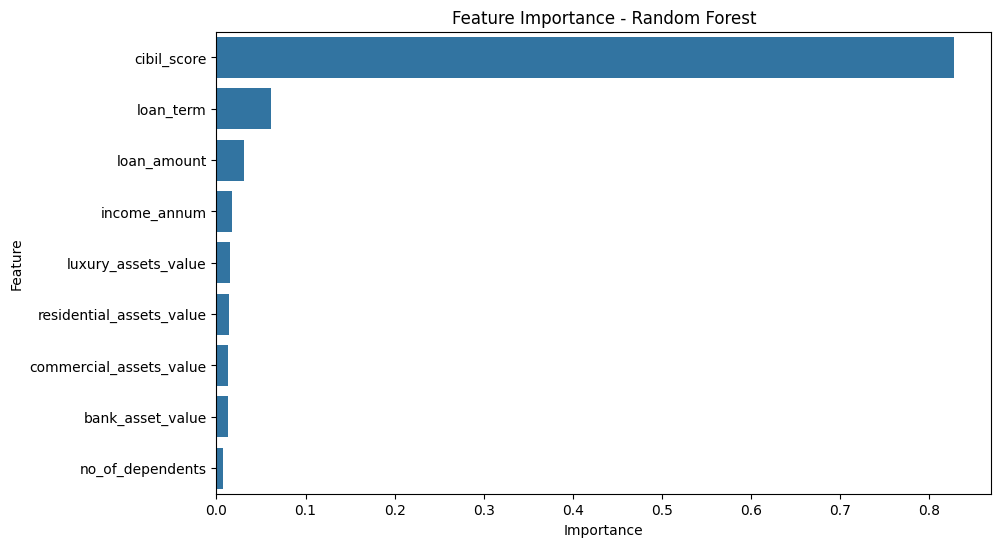

In [67]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")

plt.show()

In [68]:
results = pd.DataFrame({

'Model':[
'Logistic Regression',
'KNN',
'Naive Bayes',
'Decision Tree',
'SVM',
'Random Forest',
'XGBoost'
],

'Accuracy':[

0.9075,
0.9133,
0.9379,
0.9719,
0.9391,
0.9801,
0.9801

]

})

results.sort_values(
by='Accuracy',
ascending=False
)

,Model,Accuracy
6,XGBoost,0.9801
5,Random Forest,0.9801
3,Decision Tree,0.9719
4,SVM,0.9391
2,Naive Bayes,0.9379
1,KNN,0.9133
0,Logistic Regression,0.9075


In [69]:
train_pred = model_rf.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, train_pred))

test_pred = model_rf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, test_pred))

Train Accuracy: 1.0
Test Accuracy: 0.9800936768149883


In [70]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [71]:
import joblib

joblib.dump(model_rf, "loan_model.pkl")
joblib.dump(scaler, "scaler1.pkl")
joblib.dump(X_train.columns.tolist(), "feature_names.pkl")

['feature_names.pkl']

In [72]:
print(y.value_counts())

loan_status_ Rejected
0    2656
1    1613
Name: count, dtype: int64


In [74]:
print(X_train.columns.tolist())

['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
